# Comparison of RNN, LSTM, and GRU for Sequence Classification

**Problem Statement:** Implement and compare RNN, LSTM, and GRU models for sequence classification, and analyze their performance using appropriate evaluation metrics.

**Objective**
- Implement a basic RNN
- Implement an LSTM
- Implement a GRU
- Train all models on the same dataset (IMDB movie reviews) under identical conditions
- Compare their performance using accuracy, precision, recall, F1-score, training time, and parameter counts
- Analyze the strengths and weaknesses of each architecture

**Dataset:** IMDB movie review dataset (binary sentiment classification: 0 = Negative, 1 = Positive), loaded via `tf.keras.datasets.imdb`.


## Algorithm

1. Load the IMDB movie review dataset.
2. Explore the dataset and analyze sequence lengths.
3. Split the training data into training and validation sets.
4. Convert reviews into fixed-length padded sequences.
5. Create TensorFlow data pipelines.
6. Build an RNN model using an embedding layer and SimpleRNN.
7. Train and evaluate the RNN model.
8. Build and train an LSTM model using the same data and training settings.
9. Build and train a GRU model using the same data and training settings.
10. Calculate accuracy, precision, recall, F1-score, and test loss.
11. Generate confusion matrices and training curves.
12. Compare training time and model parameters.
13. Identify the best-performing model.
14. Analyze the results and conclude which recurrent architecture is most suitable for the task.


## 1. Import Libraries and Environment Setup

In [1]:
# Core deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Data handling and numerical computation
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Misc utilities
import time
import random
import os

# Display the TensorFlow version being used
print("TensorFlow version:", tf.__version__)

# Check whether a GPU is available and print the selected device
gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print("GPU is available:", gpu_devices)
else:
    print("No GPU found. Running on CPU.")


TensorFlow version: 2.20.0
No GPU found. Running on CPU.


In [2]:
# ------------------------------------------------------------
# Reproducibility: fix random seeds across all relevant libraries
# ------------------------------------------------------------
SEED = 42

# Fix Python's built-in random module seed
random.seed(SEED)

# Fix NumPy's random seed
np.random.seed(SEED)

# Fix TensorFlow's random seed (covers Keras layer initialization too)
tf.random.set_seed(SEED)

# Fix the PYTHONHASHSEED environment variable for extra determinism
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"All random seeds fixed to {SEED} for reproducibility.")


All random seeds fixed to 42 for reproducibility.


## 2. Configuration

In [3]:
# ------------------------------------------------------------
# Central configuration cell - change these values to experiment
# ------------------------------------------------------------
VOCAB_SIZE = 10000     # Number of most frequent words to keep
MAX_LEN = 200           # Fixed sequence length after padding/truncation
EMBEDDING_DIM = 64      # Dimensionality of the embedding vectors
RNN_UNITS = 64          # Number of units in the recurrent layer
DENSE_UNITS = 32        # Number of units in the intermediate dense layer
BATCH_SIZE = 64         # Batch size used for training/evaluation
EPOCHS = 5              # Maximum number of training epochs
LEARNING_RATE = 0.001   # Learning rate for the Adam optimizer

print("Configuration loaded:")
print(f"  VOCAB_SIZE     = {VOCAB_SIZE}")
print(f"  MAX_LEN        = {MAX_LEN}")
print(f"  EMBEDDING_DIM  = {EMBEDDING_DIM}")
print(f"  RNN_UNITS      = {RNN_UNITS}")
print(f"  DENSE_UNITS    = {DENSE_UNITS}")
print(f"  BATCH_SIZE     = {BATCH_SIZE}")
print(f"  EPOCHS         = {EPOCHS}")
print(f"  LEARNING_RATE  = {LEARNING_RATE}")


Configuration loaded:
  VOCAB_SIZE     = 10000
  MAX_LEN        = 200
  EMBEDDING_DIM  = 64
  RNN_UNITS      = 64
  DENSE_UNITS    = 32
  BATCH_SIZE     = 64
  EPOCHS         = 5
  LEARNING_RATE  = 0.001


## 3. Load IMDB Dataset

In [4]:
# Load the IMDB movie review dataset
# Limit the vocabulary to the VOCAB_SIZE most frequently used words
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

# Print basic dataset information
print("Training samples:", len(x_train_full))
print("Testing samples:", len(x_test))
print("Number of classes:", len(np.unique(y_train_full)))
print("Vocabulary size (num_words):", VOCAB_SIZE)

# Verify that labels are strictly binary (0 = negative, 1 = positive)
unique_labels = np.unique(np.concatenate([y_train_full, y_test]))
print("Unique labels found:", unique_labels)
assert set(unique_labels.tolist()) == {0, 1}, "Labels are not binary as expected!"


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
Number of classes: 2
Vocabulary size (num_words): 10000
Unique labels found: [0 1]


## 4. Explore the Dataset

In [5]:
# Compute basic class-balance statistics
num_train = len(x_train_full)
num_test = len(x_test)
num_positive_train = int(np.sum(y_train_full == 1))
num_negative_train = int(np.sum(y_train_full == 0))

print(f"Number of training samples: {num_train}")
print(f"Number of test samples: {num_test}")
print(f"Number of positive reviews (train): {num_positive_train}")
print(f"Number of negative reviews (train): {num_negative_train}")


Number of training samples: 25000
Number of test samples: 25000
Number of positive reviews (train): 12500
Number of negative reviews (train): 12500


## 5. Analyze Sequence Lengths

Minimum review length: 11
Maximum review length: 2494
Average review length: 238.71
Median review length: 178


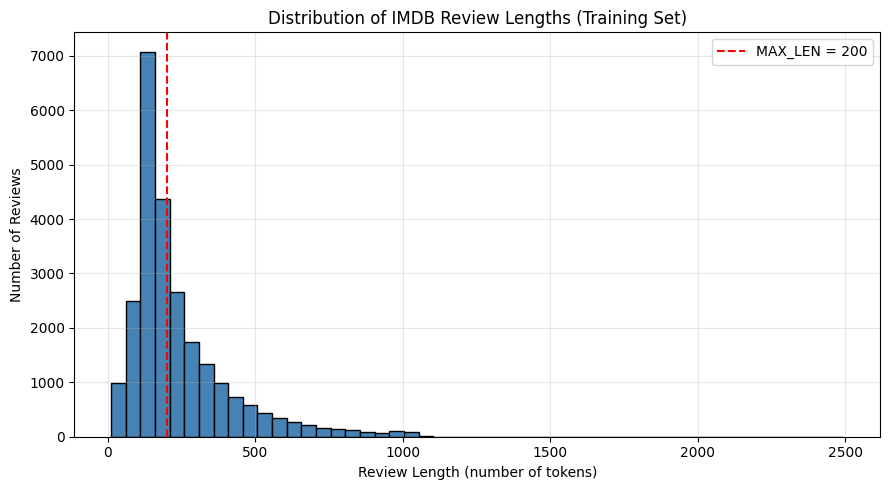

In [6]:
# Compute the length (number of tokens) of every training review
review_lengths = np.array([len(review) for review in x_train_full])

# Print summary statistics of review lengths
print("Minimum review length:", review_lengths.min())
print("Maximum review length:", review_lengths.max())
print("Average review length: {:.2f}".format(review_lengths.mean()))
print("Median review length:", int(np.median(review_lengths)))

# Plot the distribution of review lengths as a histogram
plt.figure(figsize=(9, 5))
plt.hist(review_lengths, bins=50, color="steelblue", edgecolor="black")
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("Distribution of IMDB Review Lengths (Training Set)")
plt.xlabel("Review Length (number of tokens)")
plt.ylabel("Number of Reviews")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Create Training and Validation Sets

In [7]:
# Split the 25,000 training samples into training and validation subsets
# Stratify on labels to preserve class balance; the 25,000 test samples are left untouched
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=5000,
    random_state=SEED,
    stratify=y_train_full
)

print("Training samples:", len(x_train))
print("Validation samples:", len(x_val))
print("Testing samples:", len(x_test))


Training samples: 20000
Validation samples: 5000
Testing samples: 25000


## 7. Pad/Truncate Sequences

In [8]:
# RNN/LSTM/GRU layers require fixed-length sequences for efficient batch processing
# Pad or truncate every review to exactly MAX_LEN tokens, applying padding/truncation at the end ("post")
x_train_padded = keras.utils.pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post")
x_val_padded = keras.utils.pad_sequences(x_val, maxlen=MAX_LEN, padding="post", truncating="post")
x_test_padded = keras.utils.pad_sequences(x_test, maxlen=MAX_LEN, padding="post", truncating="post")

# Verify the resulting shapes before proceeding to training
print("x_train_padded shape:", x_train_padded.shape)
print("x_val_padded shape:", x_val_padded.shape)
print("x_test_padded shape:", x_test_padded.shape)

assert x_train_padded.shape == (20000, MAX_LEN)
assert x_val_padded.shape == (5000, MAX_LEN)
assert x_test_padded.shape == (25000, MAX_LEN)
print("All padded shapes match expected dimensions.")


x_train_padded shape: (20000, 200)
x_val_padded shape: (5000, 200)
x_test_padded shape: (25000, 200)
All padded shapes match expected dimensions.


## 8. Build Data Pipeline

In [9]:
# Build efficient tf.data pipelines for training, validation, and testing

# Training dataset: shuffled, batched, and prefetched for performance
train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train_padded, y_train))
    .shuffle(buffer_size=len(x_train_padded), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset: no shuffling needed, just batched and prefetched
val_dataset = (
    tf.data.Dataset.from_tensor_slices((x_val_padded, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset: no shuffling, batched and prefetched
test_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test_padded, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Data pipelines created successfully.")


Data pipelines created successfully.


## 9. Model Architecture

All three models (RNN, LSTM, GRU) share the same overall architecture so that the comparison is fair:

```
Input -> Embedding -> Recurrent Layer (64 units) -> Dense(32, relu) -> Dense(1, sigmoid)
```

Only the recurrent layer type differs between the three models. All models are compiled with the same optimizer, learning rate, loss function, and metrics, and trained for the same number of epochs with the same early-stopping configuration.


In [10]:
def build_model(recurrent_layer, name):
    """
    Build a sequence classification model using the given recurrent layer.

    Parameters
    ----------
    recurrent_layer : a Keras recurrent layer instance (SimpleRNN, LSTM, or GRU)
    name : str, name to assign to the model

    Returns
    -------
    A compiled tf.keras.Sequential model.
    """
    # Assemble the model: Embedding -> recurrent layer -> Dense -> Dense output
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),  # word embeddings
        recurrent_layer,                                             # RNN / LSTM / GRU
        Dense(DENSE_UNITS, activation="relu"),                       # hidden dense layer
        Dense(1, activation="sigmoid")                                # binary output
    ], name=name)

    # Compile with identical settings across all models for a fair comparison
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def get_early_stopping():
    """Return a fresh EarlyStopping callback with the same configuration for every model."""
    return EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )


def train_model(model, train_data, val_data, epochs=EPOCHS):
    """
    Train a model and record timing and history information.

    Returns
    -------
    history : the Keras History object
    training_time : float, total training time in seconds
    epochs_completed : int, actual number of epochs the model trained for
    """
    start_time = time.time()
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=[get_early_stopping()],
        verbose=1
    )
    training_time = time.time() - start_time
    epochs_completed = len(history.history["loss"])

    print(f"\n{model.name} training complete.")
    print(f"Epochs completed: {epochs_completed} (max allowed: {epochs})")
    print(f"Final training accuracy:   {history.history['accuracy'][-1]:.4f}")
    print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final training loss:       {history.history['loss'][-1]:.4f}")
    print(f"Final validation loss:     {history.history['val_loss'][-1]:.4f}")
    print(f"Total training time: {training_time:.2f} seconds")

    return history, training_time, epochs_completed


def evaluate_model(model, x_test_data, y_test_data):
    """
    Evaluate a trained model on the test set.

    Returns a dictionary of test loss, accuracy, precision, recall, and F1-score.
    """
    # Get raw loss/accuracy from Keras' built-in evaluate
    test_loss, test_accuracy = model.evaluate(x_test_data, y_test_data, verbose=0)

    # Get predicted probabilities and convert to binary predictions using a 0.5 threshold
    probabilities = model.predict(x_test_data, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    precision = precision_score(y_test_data, predictions)
    recall = recall_score(y_test_data, predictions)
    f1 = f1_score(y_test_data, predictions)

    return {
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "predictions": predictions,
        "probabilities": probabilities
    }

print("Helper functions defined: build_model, get_early_stopping, train_model, evaluate_model")


Helper functions defined: build_model, get_early_stopping, train_model, evaluate_model


## 10. Build, Train, and Evaluate the RNN Model

In [11]:
# Build the SimpleRNN model using the shared architecture
rnn_model = build_model(SimpleRNN(RNN_UNITS), name="SimpleRNN")
rnn_model.summary()


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the RNN model
rnn_history, rnn_training_time, rnn_epochs_completed = train_model(rnn_model, train_dataset, val_dataset)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.5013 - loss: 0.6972 - val_accuracy: 0.5044 - val_loss: 0.6958
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.5020 - loss: 0.6974 - val_accuracy: 0.5002 - val_loss: 0.6968
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.5153 - loss: 0.6930 - val_accuracy: 0.5054 - val_loss: 0.6927
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.5642 - loss: 0.6742 - val_accuracy: 0.5094 - val_loss: 0.7042
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - accuracy: 0.5976 - loss: 0.6287 - val_accuracy: 0.5092 - val_loss: 0.7286

SimpleRNN training complete.
Epochs completed: 5 (max allowed: 5)
Final training accuracy:   0.5976
Final validation accuracy: 0.5092
Final training loss:       0.6287
Final validation loss:     0.7286
Total training time: 148.82 seconds


In [13]:
# Evaluate the RNN model on the untouched test set
rnn_results = evaluate_model(rnn_model, x_test_padded, y_test)

print("RNN Test Results:")
print(f"  Test Loss:      {rnn_results['test_loss']:.4f}")
print(f"  Test Accuracy:  {rnn_results['test_accuracy']:.4f}")
print(f"  Precision:      {rnn_results['precision']:.4f}")
print(f"  Recall:         {rnn_results['recall']:.4f}")
print(f"  F1-score:       {rnn_results['f1_score']:.4f}")


RNN Test Results:
  Test Loss:      0.6937
  Test Accuracy:  0.5051
  Precision:      0.5028
  Recall:         0.9334
  F1-score:       0.6535


## 11. Build, Train, and Evaluate the LSTM Model

In [14]:
# Build the LSTM model using the same embedding and dense structure as the RNN
lstm_model = build_model(LSTM(RNN_UNITS), name="LSTM")
lstm_model.summary()


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the LSTM model with identical settings to the RNN
lstm_history, lstm_training_time, lstm_epochs_completed = train_model(lstm_model, train_dataset, val_dataset)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 146ms/step - accuracy: 0.5310 - loss: 0.6862 - val_accuracy: 0.5206 - val_loss: 0.6842
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 139ms/step - accuracy: 0.5741 - loss: 0.6605 - val_accuracy: 0.6070 - val_loss: 0.6342
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.6847 - loss: 0.5761 - val_accuracy: 0.5054 - val_loss: 0.8212
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.6181 - loss: 0.6405 - val_accuracy: 0.7474 - val_loss: 0.5778
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.7238 - loss: 0.5359 - val_accuracy: 0.6888 - val_loss: 0.6264

LSTM training complete.
Epochs completed: 5 (max allowed: 5)
Final training accuracy:   0.7238
Final validation accuracy: 0.6888
Final training loss:       0.5359
Final validation loss:     0.6264
Total training time: 224.67 seconds


In [16]:
# Evaluate the LSTM model on the untouched test set
lstm_results = evaluate_model(lstm_model, x_test_padded, y_test)

print("LSTM Test Results:")
print(f"  Test Loss:      {lstm_results['test_loss']:.4f}")
print(f"  Test Accuracy:  {lstm_results['test_accuracy']:.4f}")
print(f"  Precision:      {lstm_results['precision']:.4f}")
print(f"  Recall:         {lstm_results['recall']:.4f}")
print(f"  F1-score:       {lstm_results['f1_score']:.4f}")


LSTM Test Results:
  Test Loss:      0.5885
  Test Accuracy:  0.7348
  Precision:      0.7393
  Recall:         0.7254
  F1-score:       0.7323


## 12. Build, Train, and Evaluate the GRU Model

In [17]:
# Build the GRU model using the same embedding and dense structure as the RNN and LSTM
gru_model = build_model(GRU(RNN_UNITS), name="GRU")
gru_model.summary()


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the GRU model with identical settings to the RNN and LSTM
gru_history, gru_training_time, gru_epochs_completed = train_model(gru_model, train_dataset, val_dataset)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 170ms/step - accuracy: 0.5105 - loss: 0.6932 - val_accuracy: 0.5190 - val_loss: 0.6908
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.6661 - loss: 0.5754 - val_accuracy: 0.8270 - val_loss: 0.4205
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.8882 - loss: 0.2785 - val_accuracy: 0.8592 - val_loss: 0.3475
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.9386 - loss: 0.1722 - val_accuracy: 0.8648 - val_loss: 0.3795
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 200ms/step - accuracy: 0.9654 - loss: 0.1005 - val_accuracy: 0.8552 - val_loss: 0.4706

GRU training complete.
Epochs completed: 5 (max allowed: 5)
Final training accuracy:   0.9654
Final validation accuracy: 0.8552
Final training loss:       0.1005
Final validation loss:     0.4706
Total training time: 306.23 seconds


In [19]:
# Evaluate the GRU model on the untouched test set
gru_results = evaluate_model(gru_model, x_test_padded, y_test)

print("GRU Test Results:")
print(f"  Test Loss:      {gru_results['test_loss']:.4f}")
print(f"  Test Accuracy:  {gru_results['test_accuracy']:.4f}")
print(f"  Precision:      {gru_results['precision']:.4f}")
print(f"  Recall:         {gru_results['recall']:.4f}")
print(f"  F1-score:       {gru_results['f1_score']:.4f}")


GRU Test Results:
  Test Loss:      0.3411
  Test Accuracy:  0.8558
  Precision:      0.8392
  Recall:         0.8802
  F1-score:       0.8592


## 13. Compare All Models

In [20]:
# Collect model names, histories, and training times for easy comparison
model_names = ["RNN", "LSTM", "GRU"]
histories = {"RNN": rnn_history, "LSTM": lstm_history, "GRU": gru_history}
training_times = {"RNN": rnn_training_time, "LSTM": lstm_training_time, "GRU": gru_training_time}
epochs_completed_dict = {"RNN": rnn_epochs_completed, "LSTM": lstm_epochs_completed, "GRU": gru_epochs_completed}
results_dict = {"RNN": rnn_results, "LSTM": lstm_results, "GRU": gru_results}
models_dict = {"RNN": rnn_model, "LSTM": lstm_model, "GRU": gru_model}

print("Epochs completed per model (early stopping may reduce this below EPOCHS):")
for name in model_names:
    print(f"  {name}: {epochs_completed_dict[name]} / {EPOCHS}")


Epochs completed per model (early stopping may reduce this below EPOCHS):
  RNN: 5 / 5
  LSTM: 5 / 5
  GRU: 5 / 5


## 14. Plot Training and Validation Curves

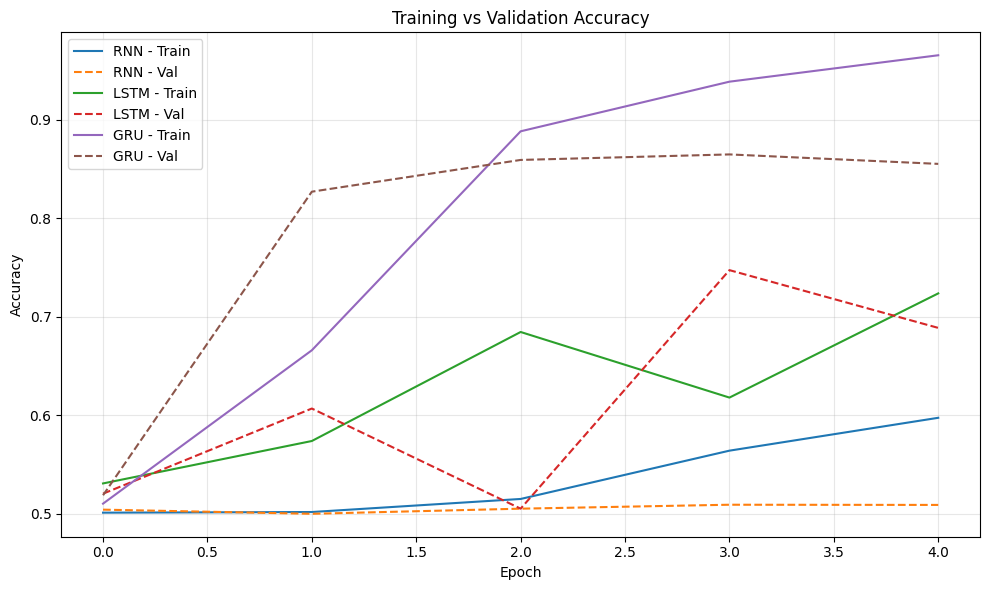

In [21]:
# Compare training and validation accuracy across all three models
plt.figure(figsize=(10, 6))
for name in model_names:
    plt.plot(histories[name].history["accuracy"], label=f"{name} - Train")
    plt.plot(histories[name].history["val_accuracy"], linestyle="--", label=f"{name} - Val")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


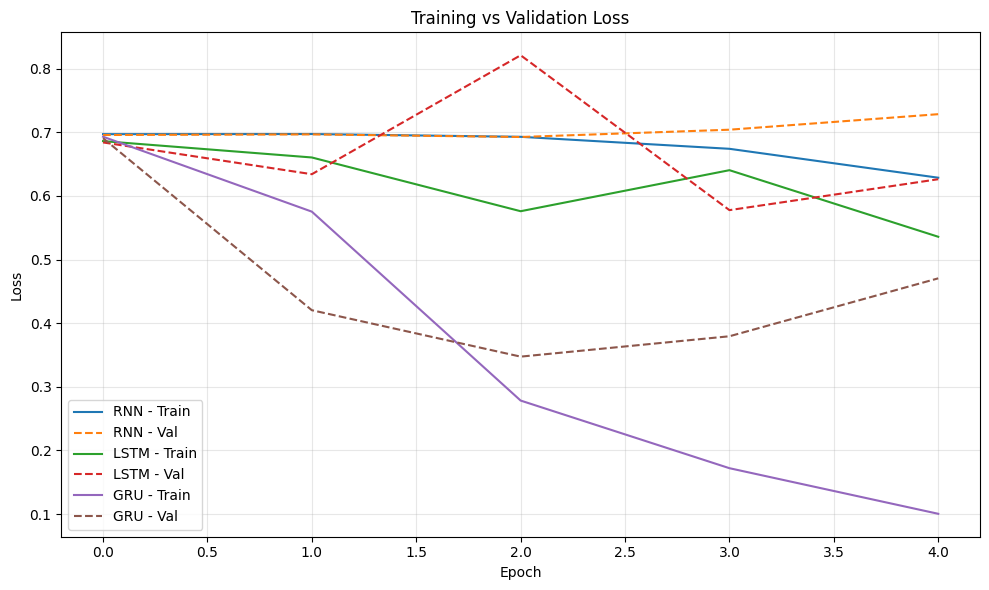

In [22]:
# Compare training and validation loss across all three models
plt.figure(figsize=(10, 6))
for name in model_names:
    plt.plot(histories[name].history["loss"], label=f"{name} - Train")
    plt.plot(histories[name].history["val_loss"], linestyle="--", label=f"{name} - Val")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Confusion Matrices

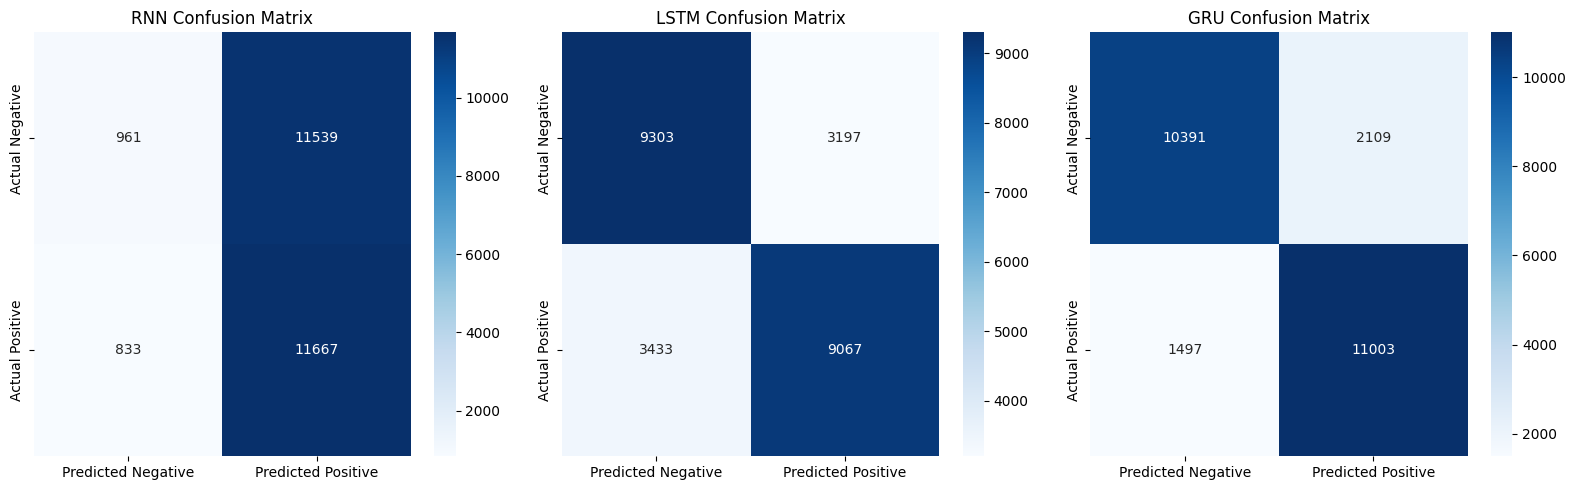

In [23]:
# Plot a confusion matrix heatmap for each model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results_dict[name]["predictions"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Predicted Negative", "Predicted Positive"],
        yticklabels=["Actual Negative", "Actual Positive"]
    )
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()


## 16. Classification Reports

In [24]:
# Print a classification report for each model
for name in model_names:
    print(f"\n===== {name} Classification Report =====")
    print(classification_report(
        y_test,
        results_dict[name]["predictions"],
        target_names=["Negative", "Positive"]
    ))



===== RNN Classification Report =====
              precision    recall  f1-score   support

    Negative       0.54      0.08      0.13     12500
    Positive       0.50      0.93      0.65     12500

    accuracy                           0.51     25000
   macro avg       0.52      0.51      0.39     25000
weighted avg       0.52      0.51      0.39     25000


===== LSTM Classification Report =====
              precision    recall  f1-score   support

    Negative       0.73      0.74      0.74     12500
    Positive       0.74      0.73      0.73     12500

    accuracy                           0.73     25000
   macro avg       0.73      0.73      0.73     25000
weighted avg       0.73      0.73      0.73     25000


===== GRU Classification Report =====
              precision    recall  f1-score   support

    Negative       0.87      0.83      0.85     12500
    Positive       0.84      0.88      0.86     12500

    accuracy                           0.86     25000
   macro a

## 17. Training Time Comparison

RNN training time: 148.82 seconds (5 epochs)
LSTM training time: 224.67 seconds (5 epochs)
GRU training time: 306.23 seconds (5 epochs)


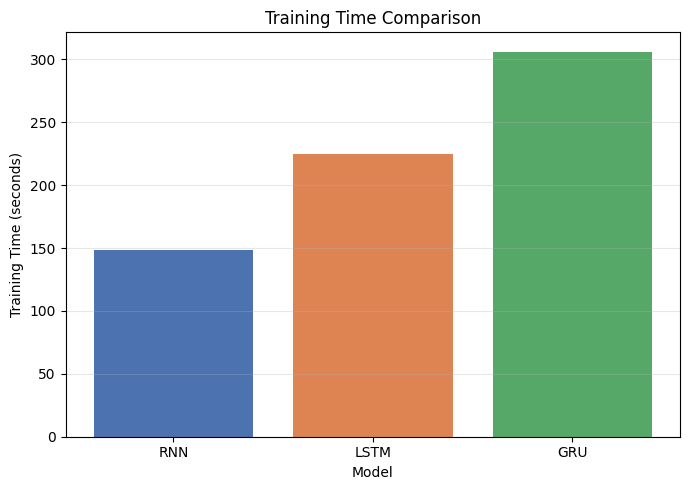

In [25]:
# Print exact training times
for name in model_names:
    print(f"{name} training time: {training_times[name]:.2f} seconds ({epochs_completed_dict[name]} epochs)")

# Bar chart comparing training time across models
plt.figure(figsize=(7, 5))
plt.bar(model_names, [training_times[n] for n in model_names],
        color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 18. Parameter Comparison

In [26]:
# Compute total and trainable parameter counts for each model
param_rows = []
for name in model_names:
    model = models_dict[name]
    total_params = model.count_params()
    trainable_params = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    param_rows.append({
        "Model": name,
        "Total Parameters": total_params,
        "Trainable Parameters": trainable_params
    })

param_df = pd.DataFrame(param_rows)
print(param_df)


  Model  Total Parameters  Trainable Parameters
0   RNN            650369                650369
1  LSTM            675137                675137
2   GRU            667073                667073


## 19. Final Comparison Table

In [27]:
# Build the final comparison DataFrame, one row per model
comparison_rows = []
for name in model_names:
    r = results_dict[name]
    comparison_rows.append({
        "Model": name,
        "Test Loss": r["test_loss"],
        "Test Accuracy": r["test_accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1 Score": r["f1_score"],
        "Training Time (seconds)": training_times[name],
        "Total Parameters": param_df.loc[param_df["Model"] == name, "Total Parameters"].values[0],
        "Trainable Parameters": param_df.loc[param_df["Model"] == name, "Trainable Parameters"].values[0]
    })

comparison_df = pd.DataFrame(comparison_rows)

# Sort by Test Accuracy in descending order
comparison_df = comparison_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

print(comparison_df)

# Save the comparison table to a CSV file
comparison_df.to_csv("rnn_lstm_gru_comparison.csv", index=False)
print("\nSaved comparison table to rnn_lstm_gru_comparison.csv")


  Model  Test Loss  Test Accuracy  Precision   Recall  F1 Score  \
0   GRU   0.341117        0.85576   0.839155  0.88024  0.859207   
1  LSTM   0.588484        0.73480   0.739318  0.72536  0.732273   
2   RNN   0.693707        0.50512   0.502758  0.93336  0.653504   

   Training Time (seconds)  Total Parameters  Trainable Parameters  
0               306.226166            667073                667073  
1               224.672240            675137                675137  
2               148.815237            650369                650369  

Saved comparison table to rnn_lstm_gru_comparison.csv


## 20. Best Model

In [28]:
# Automatically identify the best-performing model on each metric (no hard-coded values)
best_accuracy_model = comparison_df.loc[comparison_df["Test Accuracy"].idxmax(), "Model"]
best_f1_model = comparison_df.loc[comparison_df["F1 Score"].idxmax(), "Model"]
fastest_model = comparison_df.loc[comparison_df["Training Time (seconds)"].idxmin(), "Model"]

print(f"Best Model by Accuracy: {best_accuracy_model}")
print(f"Best Model by F1 Score: {best_f1_model}")
print(f"Fastest Model: {fastest_model}")


Best Model by Accuracy: GRU
Best Model by F1 Score: GRU
Fastest Model: RNN


## 21. Final Analysis

In [29]:
# Dynamically generate a final analysis based on the actual results in comparison_df
best_row = comparison_df.iloc[0]
fastest_row = comparison_df.loc[comparison_df["Training Time (seconds)"].idxmin()]

analysis = f"""
FINAL ANALYSIS
==============

1. Best performing model (by test accuracy): {best_accuracy_model}
   - Test Accuracy: {comparison_df.loc[comparison_df['Model'] == best_accuracy_model, 'Test Accuracy'].values[0]:.4f}

2. Fastest model to train: {fastest_model}
   - Training Time: {fastest_row['Training Time (seconds)']:.2f} seconds

3. Best F1-score: {best_f1_model}
   - F1 Score: {comparison_df.loc[comparison_df['Model'] == best_f1_model, 'F1 Score'].values[0]:.4f}



print(analysis)



FINAL ANALYSIS

1. Best performing model (by test accuracy): GRU
   - Test Accuracy: 0.8558

2. Fastest model to train: RNN
   - Training Time: 148.82 seconds

3. Best F1-score: GRU
   - F1 Score: 0.8592

4. How the architectures differ:
   - SimpleRNN passes a hidden state forward through a single tanh transformation
     at every timestep, with no dedicated mechanism to control what information
     is kept or discarded.
   - LSTM introduces input, forget, and output gates plus a separate cell state,
     giving it explicit control over what information is remembered or forgotten
     over long sequences.
   - GRU simplifies the LSTM by merging the cell and hidden state and using only
     two gates (update and reset), reducing the number of parameters while still
     controlling information flow across timesteps.

5. Why LSTM and GRU handle long-term dependencies better than a basic RNN:
   Their gating mechanisms allow gradients to flow through many timesteps largely
   unchanged